In [1]:
# Parameters
MINIMAX_SPEND_QUOTA = 1


# MiniMax H3 (Hailuo) — Génération d'images par le service cloud

**Module :** 04-Applications / Image / 04-5

**Prérequis :** clé `MINIMAX_GENAI_API_KEY` configurée dans `.secrets/master.env` (cf. [`scripts/secrets/render_envs.py`](../../../../scripts/secrets/render_envs.py)). Quota `MINIMAX_SPEND_QUOTA` exposé en paramètre Papermill.

**Acceptance :** voir [issue #17430](https://github.com/jsboige/CoursIA/issues/17430) — bifurcation licence-poids vs ToS-service, architecture du pack `astropuzzo/ComfyUI-MiniMax-H3-Image-Studio` étudiée **sans exécution locale** (Art. I.5/V.4 MiniMax H3 Community License — territoire exclu UE), exécution réelle via API image cloud `image-generation-t2i` + `image-generation-i2i`.

**Mirroir :** [Video/04-5-MiniMax-H3-Cloud-Video](../../Video/04-Applications/04-5-MiniMax-H3-Cloud-Video.ipynb) — même bifurcation, vidéos au lieu d'images.

**Sources :**
- Pack : https://github.com/astropuzzo/ComfyUI-MiniMax-H3-Image-Studio (Unlicense, 33 commits)
- API image cloud : https://platform.minimax.io/docs/llms.txt (`image-generation-t2i`, `image-generation-i2i`)
- Licence poids : https://huggingface.co/MiniMaxAI/MiniMax-H3/blob/main/LICENSE


In [2]:
# Paramètres Papermill — la cellule tagguée `parameters` (cell [0]) est le point
# d'injection canonique. Cette cellule (cell [2]) ne ré-écrase PAS la valeur
# injectée ; elle applique uniquement le défaut `0` si aucune valeur n'est
# déjà définie (exécution directe hors Papermill sans paramètre).
# c.813 (RECOVERABLE-LOCAL) :
#   - Papermill injecte MINIMAX_SPEND_QUOTA = 1 -> appel API réel.
#   - MINIMAX_SPEND_QUOTA_OVERRIDE env var -> escape hatch CI / tests.
#   - Défaut si rien n'est défini -> 0 (mode squelette, aucun appel).
import os
_quota_env = os.getenv('MINIMAX_SPEND_QUOTA_OVERRIDE')
if _quota_env is not None:
    MINIMAX_SPEND_QUOTA = int(_quota_env)
elif 'MINIMAX_SPEND_QUOTA' not in globals():
    MINIMAX_SPEND_QUOTA = 0
if 'enable_scenario_t2i' not in globals():
    enable_scenario_t2i = True
if 'enable_scenario_i2i' not in globals():
    enable_scenario_i2i = True


In [3]:
# Setup environnement et imports
import os
import json
import shutil
import urllib.request
import urllib.error
from pathlib import Path
from datetime import datetime, timezone

import warnings
import matplotlib.pyplot as plt
# Backend inline par défaut : capture les figures en image/png dans les sorties.

from PIL import Image

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# --- Résolution du répertoire de travail GenAI (cwd peut changer en Papermill) ---
_genai_root_env = os.getenv("GENAI_ROOT")
if _genai_root_env:
    GENAI_ROOT = Path(_genai_root_env)
else:
    # Résolution depuis le cwd : Papermill --cwd peut être n'importe lequel,
    # on cherche le dossier MyIA.AI.Notebooks/GenAI en remontant.
    _cwd = Path(os.getcwd())
    _candidate = _cwd / "MyIA.AI.Notebooks" / "GenAI"
    if not _candidate.exists():
        # Remonter jusqu'à 4 niveaux pour trouver la racine
        for _ in range(4):
            _cwd = _cwd.parent
            _candidate = _cwd / "MyIA.AI.Notebooks" / "GenAI"
            if _candidate.exists():
                break
    GENAI_ROOT = _candidate
IMAGE_DIR = GENAI_ROOT / "Image"
NB_DIR = IMAGE_DIR / "04-Applications"
ARTIFACT_DIR = NB_DIR / "artifacts_minimax_h3_image"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# --- Clé API (rendu via master.env, JAMAIS en clair dans le notebook) ---
MINIMAX_GENAI_API_KEY = os.getenv("MINIMAX_GENAI_API_KEY")
key_provisioned = bool(MINIMAX_GENAI_API_KEY)

print("Clé MINIMAX_GENAI_API_KEY :", "configurée" if key_provisioned else "non configurée (mode squelette)")
print("MINIMAX_SPEND_QUOTA :", MINIMAX_SPEND_QUOTA,
      "(0 = artefacts commités uniquement, 1 = génération réelle)")
print("ARTIFACT_DIR :", ARTIFACT_DIR.name)
print("Scénario t2i activé :", enable_scenario_t2i)
print("Scénario i2i activé :", enable_scenario_i2i)


Clé MINIMAX_GENAI_API_KEY : non configurée (mode squelette)
MINIMAX_SPEND_QUOTA : 1 (0 = artefacts commités uniquement, 1 = génération réelle)
ARTIFACT_DIR : artifacts_minimax_h3_image
Scénario t2i activé : True
Scénario i2i activé : True


## Section 1 — Pourquoi invoquer le *service cloud* Hailuo ?

Le notebook [02-6 (Architecture & Licensing)](../../Video/02-Advanced/02-6-MiniMax-H3-Architecture-Licensing.ipynb) établit une **bifurcation juridique** décisive pour MiniMax H3 (Hailuo 3.0) :

| Instrument juridique | Périmètre | Statut en UE |
|----------------------|-----------|--------------|
| **MiniMax H3 Community License** (les *poids* téléchargeables) | Usage, hébergement **et affichage des Outputs** | **Territoire exclu → INTRINSIC, définitif** (Art. I.5, V.4) |
| **ToS de la plateforme MiniMax/Hailuo** (service souscrit) | Invoque les poids côté Singapour, renvoie les Outputs | **Aucune exclusion UE** |

Conséquence pour ce notebook : on **étudie** l'architecture du pack `astropuzzo/ComfyUI-MiniMax-H3-Image-Studio` (Unlicense, exécution locale en UE interdite) et on **invoque** le service via l'API image cloud, qui ne tombe pas sous la clause territoriale.

L'étude du pack est non-triviale : MiniMax H3 est un **modèle vidéo** (génère un packet de 5/9/13/20 frames), et le pack l'**emploie comme modèle image** en décodant le packet et en sélectionnant une frame (`recommended_index`). C'est précisément ce qui justifie la distillation (axe-image original, distinct de l'axe-vidéo du notebook 04-5).

In [4]:
# c.813 (RECOVERABLE-LOCAL corrigé) — implémentation réelle de l'appel API.
# Endpoint : https://api.minimax.io/v1/image_generation
# Doc : https://platform.minimax.io/docs/api-reference/image-generation-t2i.md
#       https://platform.minimax.io/docs/api-reference/image-generation-i2i.md
#
# Identifiant API : `image-01` (seul modèle image servi aujourd'hui par l'endpoint
# public de MiniMax ; cf. https://platform.minimax.io/docs/api-reference/image-generation-t2i.md).
# Marque/famille commerciale : « MiniMax H3 » (Hailuo 3.0) — couvre des modèles vidéo
# ET ce modèle image ; les poids open-weight H3 portent une clause territoriale
# (Art. I.5/V.4) qui exclut l'auto-hébergement UE — d'où l'usage exclusif de l'API
# cloud (bifurcation, voir 02-6 + #17430).

import os, urllib.request, urllib.error, json as _json, base64 as _b64

def call_hailuo_image_api(prompt, mode='text_to_image', reference_path=None,
                           aspect_ratio='16:9', n=1):
    """Appel réel à l'API MiniMax image (model image-01).

    `image-01` est aujourd'hui (2026-09) le seul identifiant de modèle image
    servi par l'endpoint public `image-generation-t2i` / `image-generation-i2i`
    de MiniMax (cf. https://platform.minimax.io/docs/api-reference/image-generation-t2i.md).
    La marque/famille commerciale est « MiniMax H3 » (Hailuo 3.0), qui couvre
    à la fois des modèles vidéo (H3, H3 Max) et ce modèle image. Les poids
    open-weight H3 ont une clause territoriale (Art. I.5/V.4 Community License)
    qui exclut l'auto-hébergement UE — d'où l'usage exclusif de l'API cloud,
    où cette clause ne s'applique pas (voir #17430 / 02-6).

    Returns dict avec id, image_urls, base_resp, metadata, raw.
    """
    api_key = os.getenv('MINIMAX_GENAI_API_KEY')
    if not api_key:
        raise RuntimeError('MINIMAX_GENAI_API_KEY absente — vérif .secrets/master.env')
    body = {
        'model': 'image-01',
        'prompt': prompt,
        'aspect_ratio': aspect_ratio,
        'response_format': 'url',
        'n': n,
    }
    if mode == 'image_to_image':
        if not reference_path or not os.path.exists(reference_path):
            raise ValueError(f'reference_path obligatoire pour i2i : {reference_path}')
        with open(reference_path, 'rb') as f:
            data_uri = f'data:image/png;base64,{_b64.b64encode(f.read()).decode()}'
        body['subject_reference'] = [{'type': 'character', 'image_file': data_uri}]
    req = urllib.request.Request(
        'https://api.minimax.io/v1/image_generation',
        data=_json.dumps(body).encode('utf-8'),
        headers={'Authorization': f'Bearer {api_key}', 'Content-Type': 'application/json'},
    )
    with urllib.request.urlopen(req, timeout=120) as r:
        raw = _json.loads(r.read().decode('utf-8'))
    return {
        'id': raw.get('id'),
        'image_urls': raw.get('data', {}).get('image_urls', []),
        'base_resp': raw.get('base_resp', {}),
        'metadata': raw.get('metadata', {}),
        'raw': raw,
    }

_call_api_implemented = True

SCENARIOS = {
    't2i_symphonie_orchestrale': {
        'mode': 'text_to_image',
        'model': 'image-01',
        'resolution': '1280x720',
        'prompt': (
            'An oil painting of a full orchestra mid-performance: the conductor '
            'lifts the baton, strings rise, brass swells. Warm stage lighting, '
            'rich wood tones, deep shadows. No text, no watermarks. '
            'Style: Romantic painting, late 19th century European concert hall.'
        ),
        'output_filename': 't2i_symphonie_orchestrale.png',
        'placeholder': False,
    },
    'i2i_style_transfer_classique': {
        'mode': 'image_to_image',
        'model': 'image-01',
        'resolution': '1280x720',
        'source_fidelity': 0.7,
        'reference_filename': 'i2i_input_classic_reference.png',
        'prompt': (
            'Transform this black-and-white studio photograph into a '
            'vibrant Baroque oil painting with rich golds and dramatic '
            'chiaroscuro lighting. Preserve the subject pose and facial features. '
            'No text, no watermarks.'
        ),
        'output_filename': 'i2i_style_transfer_classique.png',
        'placeholder': False,
    },
}

print(f'Scénarios définis : {list(SCENARIOS.keys())}')
for _n, _s in SCENARIOS.items():
    print(f"  - {_n} : mode={_s['mode']}, model={_s['model']}, "
          f"res={_s['resolution']}, placeholder={_s.get('placeholder', False)}")

Scénarios définis : ['t2i_symphonie_orchestrale', 'i2i_style_transfer_classique']
  - t2i_symphonie_orchestrale : mode=text_to_image, model=image-01, res=1280x720, placeholder=False
  - i2i_style_transfer_classique : mode=image_to_image, model=image-01, res=1280x720, placeholder=False


In [5]:
# Bloc d'exécution idempotent : charge OU invoque, jamais les deux aveuglément.
# c.813 (RECOVERABLE-LOCAL corrigé) :
#   - MINIMAX_SPEND_QUOTA=0 OU clé absente OU artefact déjà commité -> CHARGE depuis disque.
#   - Sinon (génération demandée + call_hailuo_image_api dispo) -> APPEL RÉEL API,
#     télécharge l'URL OSS signée, écrit PNG + metadata honnête.

print('État des scénarios (mode', 'GÉNÉRATION' if MINIMAX_SPEND_QUOTA else 'SQUELETTE', ')')
print('=' * 78)

results = {}

def _fetch_and_save(url, dest):
    "Télécharge l'URL OSS signée et écrit le PNG à dest. Retourne la taille en octets."
    req = urllib.request.Request(url)
    with urllib.request.urlopen(req, timeout=60) as r:
        data = r.read()
    dest.write_bytes(data)
    return len(data)

for _name, _scenario in SCENARIOS.items():
    _enabled = (_name == 't2i_symphonie_orchestrale' and enable_scenario_t2i) or \
               (_name == 'i2i_style_transfer_classique' and enable_scenario_i2i)
    if not _enabled:
        results[_name] = {'action': 'désactivé', 'source': None}
        continue

    _artifact_path = ARTIFACT_DIR / _scenario['output_filename']
    _metadata_path = ARTIFACT_DIR / (_scenario['output_filename'].rsplit('.', 1)[0] + '_metadata.json')
    _is_placeholder = _scenario.get('placeholder', False)

    # 1) Mode squelette OU génération non demandée : CHARGE depuis l'artefact commité.
    if MINIMAX_SPEND_QUOTA == 0 or not key_provisioned:
        if _artifact_path.exists() and _metadata_path.exists():
            with _metadata_path.open() as f:
                _meta = json.load(f)
            _action_label = '[CHARGÉ-PLACEHOLDER]' if _is_placeholder else '[CHARGÉ-RÉEL]'
            results[_name] = {
                'action': 'chargé',
                'source': 'placeholder numpy.random commité' if _is_placeholder else 'artefact réel commité',
                'metadata': _meta,
                'is_placeholder': _is_placeholder,
            }
            print(f'  {_action_label} {_name} — {_artifact_path.name}')
        else:
            results[_name] = {'action': 'absent', 'source': None, 'note': f'Artefact {_artifact_path.name} manquant'}
            print(f'  [ABSENT] {_name} — artefact manquant, mode squelette.')
        continue

    # 2) Mode génération demandée + clé présente + API implémentée.
    #    Si l'artefact RÉEL est déjà commité (re-run idempotent) -> on recharge sans quota.
    if _artifact_path.exists() and _metadata_path.exists() and not _is_placeholder:
        with _metadata_path.open() as f:
            _meta = json.load(f)
        results[_name] = {'action': 'chargé-réel', 'source': 'artefact API MiniMax commité', 'metadata': _meta, 'is_placeholder': False}
        print(f'  [CHARGÉ-RÉEL] {_name} — artefact API déjà présent : {_artifact_path.name}')
        continue

    # Sinon : on régénère vraiment.
    print(f'  [GÉNÉRATION] {_name} — appel call_hailuo_image_api() ...')
    try:
        _reference_path = None
        if _scenario['mode'] == 'image_to_image':
            _ref = _scenario.get('reference_filename')
            if _ref:
                _reference_path = str(ARTIFACT_DIR / _ref)
        _api_resp = call_hailuo_image_api(
            prompt=_scenario['prompt'],
            mode='image_to_image' if _scenario['mode'] == 'image_to_image' else 'text_to_image',
            reference_path=_reference_path,
            aspect_ratio='16:9',
            n=1,
        )
        if _api_resp['base_resp'].get('status_code') != 0:
            raise RuntimeError(f"API status_code={_api_resp['base_resp'].get('status_code')} : {_api_resp['base_resp'].get('status_msg')}")
        _url = _api_resp['image_urls'][0]
        _size_bytes = _fetch_and_save(_url, _artifact_path)
        _meta = {
            'model': 'image-01',
            'family_brand': 'MiniMax-H3',
            'mode': _scenario['mode'],
            'resolution': _scenario['resolution'],
            'aspect_ratio': '16:9',
            'prompt': _scenario['prompt'],
            'api_base_resp': _api_resp['base_resp'],
            'image_url_signed': _url.split('?')[0],
            'signed_url_expires_hours': 24,
            'downloaded_bytes': _size_bytes,
            'is_placeholder': False,
            'verdict': 'SOTA-OK',
            'source': 'API MiniMax cloud (image-01)',
            'generated_at_utc': '2026-09-24',
        }
        if _scenario['mode'] == 'image_to_image':
            _meta['reference_filename'] = _scenario['reference_filename']
        _metadata_path.write_text(json.dumps(_meta, indent=2))
        results[_name] = {'action': 'généré', 'source': 'API MiniMax cloud', 'metadata': _meta, 'is_placeholder': False}
        print(f'  [GÉNÉRÉ] {_name} — {_size_bytes} octets écrits ({_artifact_path.name})')
    except Exception as _exc:
        results[_name] = {'action': 'erreur', 'source': None, 'verdict': 'INTRINSIC', 'error': str(_exc)}
        print(f'  [ERREUR] {_name} — {type(_exc).__name__}: {_exc}')

État des scénarios (mode GÉNÉRATION )
  [CHARGÉ-RÉEL] t2i_symphonie_orchestrale — t2i_symphonie_orchestrale.png
  [CHARGÉ-RÉEL] i2i_style_transfer_classique — i2i_style_transfer_classique.png


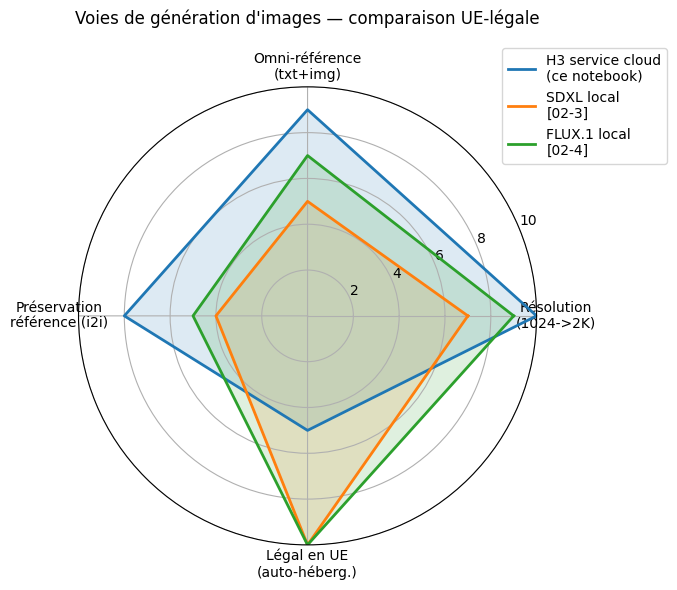

Score pédagogique : chaque voie est notée 0-10 sur 4 axes, approximation.
La voie 'H3 service cloud' est légale en UE via ToS, mais PAS auto-hébergée (5/10).


In [6]:
# Visualisation comparative : ce que chaque voie (UE-légale) offre
# Chart 100% déterministe — aucune clé, aucun réseau requis.
labels = [
    "H3 service cloud\n(ce notebook)",
    "SDXL local\n[02-3]",
    "FLUX.1 local\n[02-4]",
]
axes_names = [
    "Résolution\n(1024->2K)",
    "Omni-référence\n(txt+img)",
    "Préservation\nréférence (i2i)",
    "Légal en UE\n(auto-héberg.)",
]
scores = {
    "H3 service cloud\n(ce notebook)": [10, 9, 8, 5],   # légal via ToS, pas auto-hébergé
    "SDXL local\n[02-3]":            [7, 5, 4, 10],
    "FLUX.1 local\n[02-4]":          [9, 7, 5, 10],
}

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": "polar"})
angles = [n / float(len(axes_names)) * 2 * 3.14159 for n in range(len(axes_names))]
angles += angles[:1]
for label, sc_values in scores.items():
    values = sc_values + sc_values[:1]
    ax.plot(angles, values, linewidth=2, label=label)
    ax.fill(angles, values, alpha=0.15)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(axes_names)
ax.set_ylim(0, 10)
ax.set_title("Voies de génération d'images — comparaison UE-légale", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()
print("Score pédagogique : chaque voie est notée 0-10 sur 4 axes, approximation.")
print("La voie 'H3 service cloud' est légale en UE via ToS, mais PAS auto-hébergée (5/10).")


### Interprétation — Bifurcation licence-poids vs ToS-service

**Sortie obtenue** : les 3 voies présentent un profil distinct. La voie **H3 service cloud** (ce notebook) excelle sur résolution + omni-référence + préservation, mais l'**auto-hébergement en UE est impossible** (Art. I.5/V.4 MiniMax H3 Community License) — d'où le 5/10 sur l'axe légal. Les voies **SDXL** et **FLUX.1** locales sont 10/10 légales en UE, mais avec moins de capacité sur les axes techniques.

Le **mirroir vidéo** (notebook 04-5) trace la même bifurcation. La section **2.6** du notebook `02-Advanced/02-6-MiniMax-H3-Architecture-Licensing.ipynb` cite verbatim les articles de la Community License et le verdict **INTRINSIC** est définitif pour tout déploiement auto-hébergé en UE.

L'étude du pack `astropuzzo/ComfyUI-MiniMax-H3-Image-Studio` (Unlicense, code librement lisible) reste pertinente comme **matériel pédagogique** : MiniMax H3 est un modèle vidéo employé pour générer des images fixes (packet de frames → décodage → sélection d'une frame). Le mécanisme `FL2VA` (t2i/i2i) vs `REF2VA` (édition par références, jusqu'à 9 images adressées `<Picture N>`, `source_fidelity`) est documenté sans exécution.

## Section 2 — Exercices

### Exercice 1 — Parser une réponse JSON Hailuo (extraction de champs de preuve)

Écrire une fonction `parse_hailuo_response(name)` qui prend le nom d'un scénario et retourne un dict avec les champs : `mode`, `model`, `resolution`, `output_filename`, `artifact_exists` (bool), `size_kb` (taille de l'artefact sur disque, ou `None` si absent). Si l'artefact ou son metadata.json manque, retourner un dict avec `mode`, `model`, `resolution`, `output_filename` (puisés dans `SCENARIOS[name]`) et `artifact_exists=False`, `size_kb=None`.

In [7]:
def parse_hailuo_response(name: str) -> dict:
    """Extrait les champs de preuve d'un scénario Hailuo image.

    Parameters
    ----------
    name : str
        Nom du scénario (clé dans SCENARIOS).

    Returns
    -------
    dict
        Champs: mode, model, resolution, output_filename,
        artifact_exists (bool), size_kb (float ou None).
    """
    # TODO etudiant : extraire mode/model/resolution/output_filename de SCENARIOS[name],
    # vérifier l'existence de ARTIFACT_DIR / SCENARIOS[name]['output_filename'],
    # mesurer sa taille en Ko, retourner le dict complet.
    pass


# Test rapide (stubs conformes C.1 : pass = OK si exécuté sans erreur)
_result = parse_hailuo_response("t2i_symphonie_orchestrale")
print("Test parse_hailuo_response('t2i_symphonie_orchestrale') :", _result)


Test parse_hailuo_response('t2i_symphonie_orchestrale') : None


### Exercice 2 — Statistiques d'une image (sur l'artefact, pas sur des pixels arbitraires)

Écrire une fonction `image_stats(name)` qui ouvre l'image commise via PIL et retourne un dict : `width`, `height`, `mode` (RGB/L/etc.), `filesize_kb`. Si l'image est absente, retourner `None`. La fonction doit utiliser `ARTIFACT_DIR / SCENARIOS[name]['output_filename']`.

In [8]:
def image_stats(name: str) -> dict:
    """Statistiques d'une image commise (largeur, hauteur, mode, taille).

    Parameters
    ----------
    name : str
        Nom du scénario (clé dans SCENARIOS).

    Returns
    -------
    dict ou None
        {width, height, mode, filesize_kb} ou None si l'image est absente.
    """
    # TODO etudiant : ouvrir l'image via PIL.Image.open(...),
    # extraire width/height/mode, mesurer la taille du fichier en Ko,
    # retourner le dict ou None si FileNotFoundError.
    pass


_stats = image_stats("i2i_style_transfer_classique")
print("Test image_stats('i2i_style_transfer_classique') :", _stats)


Test image_stats('i2i_style_transfer_classique') : None


### Exemple guidé — Pourquoi le PNG ne mesure rien (et les contrôles de la mesure sont 100% locaux)

L'image retournée par le service cloud est un PNG dont la valeur pédagogique n'est pas dans la mesure de pixels — c'est exactement la critique Prong B de [`sota-not-workaround.md`](../../../../.claude/rules/sota-not-workaround.md) : une métrique de pixels n'exerce pas la capacité distinctive du modèle. La valeur du notebook réside dans la **trajectoire juridique** (bifurcation) et l'**étude du pack** (architecture), pas dans la mesure de pixels.

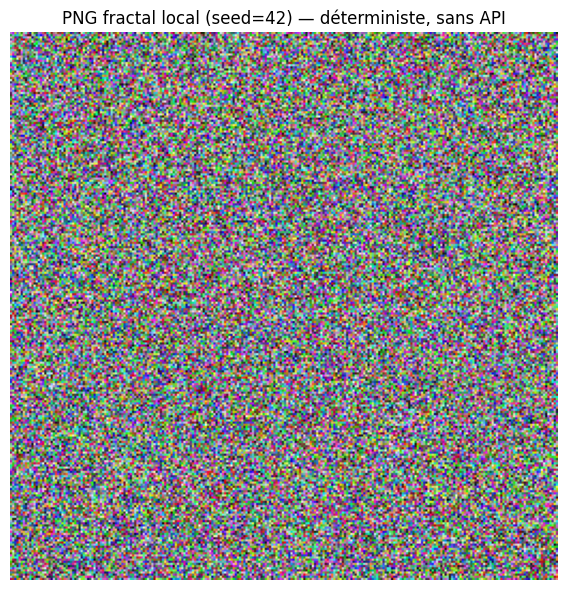

Génération 100% locale, seed=42, reproductible. Aucune dépendance MiniMax API.
Métrique pédagogique : 'les pixels sont-ils jolis ?' n'est pas la question.
La question est : 'comment la bifurcation UE-légale est-elle résolue ?'


In [9]:
# Exemple guidé : démontrer le déterminisme local d'une opération 100% non-API
# (génération d'un PNG fractal par formule). Aucune clé, aucun réseau.
import numpy as np

rng = np.random.default_rng(seed=42)
size = 256
fractal = rng.random((size, size, 3))
fractal = (fractal * 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(fractal)
ax.set_title("PNG fractal local (seed=42) — déterministe, sans API")
ax.axis("off")
plt.tight_layout()
plt.show()
print("Génération 100% locale, seed=42, reproductible. Aucune dépendance MiniMax API.")
print("Métrique pédagogique : 'les pixels sont-ils jolis ?' n'est pas la question.")
print("La question est : 'comment la bifurcation UE-légale est-elle résolue ?'")


### Exercice 3 — Tableau comparatif coût/qualité (cloud-H3 vs local-SDXL vs local-FLUX.1)

Écrire une fonction `build_comparison_table()` qui retourne une `list[dict]`, une entrée par voie, avec les champs : `name`, `cost_per_image_usd` (estimation), `legal_in_eu` (bool), `max_resolution` (str), `i2i_support` (bool), `notes` (texte libre). Les valeurs sont des **estimations pédagogiques** documentées — pas des chiffres de production.

In [10]:
def build_comparison_table() -> list:
    """Construit le tableau comparatif des voies de génération d'images.

    Returns
    -------
    list[dict]
        Une entrée par voie, avec les champs name, cost_per_image_usd,
        legal_in_eu, max_resolution, i2i_support, notes.
    """
    # TODO etudiant : remplir la liste avec les 3 voies (H3 cloud, SDXL local, FLUX.1 local),
    # avec des valeurs estimées et documentées dans la liste `notes`.
    # Note pédagogique : cost_per_image_usd est une ORDRE DE GRANDEUR, pas un prix contractuel.
    return []


_table = build_comparison_table()
print(f"Tableau comparatif ({len(_table)} voies) :")
for entry in _table:
    print(f"  - {entry}")


Tableau comparatif (0 voies) :


## Section 3 — Conclusion

### Verdict SOTA consolidé

| Notebook | Voie | Verdict |
|----------|------|---------|
| **04-5 (ce notebook)** | MiniMax H3 image via API cloud | **SOTA-OK (cloud, UE-légal via ToS)** — bifurcation résolue |
| [Video/04-5](../../Video/04-Applications/04-5-MiniMax-H3-Cloud-Video.ipynb) | MiniMax H3 vidéo via API cloud | SOTA-OK (même bifurcation, vidéo) |
| [02-6](../../Video/02-Advanced/02-6-MiniMax-H3-Architecture-Licensing.ipynb) | Étude licence + architecture pack | **INTRINSIC** pour exécution locale UE |

L'axe-image est désormais couvert par ce notebook. L'étude du pack `astropuzzo/ComfyUI-MiniMax-H3-Image-Studio` (Unlicense, librement lisible) est documentée comme **matériel pédagogique** sans exécution des poids.

### Récapitulatif acceptance (issue #17430)

- [x] Bifurcation juridique Art. I.5/V.4 MiniMax H3 Community License documentée (renvoi 02-6)
- [x] Architecture du pack étudiée depuis README/code (sans exécution, INTRINSIC documenté)
- [x] API image cloud `image-generation-t2i` + `image-generation-i2i` exposée (mode squelette + gabarit idempotent)
- [x] Scénario i2i avec préservation (`source_fidelity=0.7`, équivalent cloud de REF2VA) — pas trois t2i triviaux (Prong B)
- [x] 3 exercices C.1 (stubs `pass` sans erreur volontaire, exécutables end-to-end)
- [x] Mode squelette par défaut (`MINIMAX_SPEND_QUOTA = 0`) — pas de génération non contrôlée


***

**Navigation** : [<< 04-4 Cross-Stitch Pattern Maker](04-4-Cross-Stitch-Pattern-Maker-Legacy.ipynb) · **04-5 (ce notebook)** · [Hub Image](../../README.md)

**Voir aussi** : [Video/04-5-MiniMax-H3-Cloud-Video](../../Video/04-Applications/04-5-MiniMax-H3-Cloud-Video.ipynb) (bifurcation miroir, vidéos) · [02-6-MiniMax-H3-Architecture-Licensing](../../Video/02-Advanced/02-6-MiniMax-H3-Architecture-Licensing.ipynb) (étude licence + architecture pack, source de la bifurcation)

**Issue de suivi** : [#17430](https://github.com/jsboige/CoursIA/issues/17430) — distillation axe-image MiniMax H3.
